In [13]:
#importing libraries

from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [32]:
X,y=make_regression(n_samples=100,n_features=2,n_informative=2,n_targets=1,noise=50)

In [33]:
df=pd.DataFrame({'Feature 1':X[:,0],'Feature 2': X[:,1],'Target':y})
df.head()

,Feature 1,Feature 2,Target
0,1.715370,0.675419,16.145771
1,-0.555777,0.460897,-17.808214
2,-0.087452,-0.745536,-16.678342
3,-0.622876,-0.384064,-42.927547
4,0.223610,-0.184726,33.230801


In [34]:
df.shape

(100, 3)

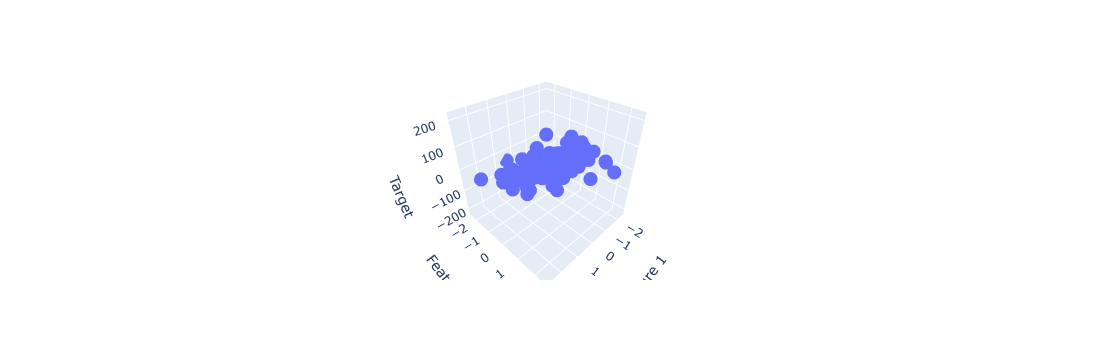

In [35]:
fig =px.scatter_3d(data_frame=df,x='Feature 1',y='Feature 2',z='Target')
fig.show()

In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()

In [38]:
LR_model=LR.fit(X_train,y_train)

In [39]:
y_pred_train=LR.predict(X_train)
y_pred_train

array([  57.37052169,  103.05914249,  -67.99607571,    8.04866181,
        -77.17548353,  144.95057032,   40.20879641,  -27.69301436,
        -26.14277715,    8.37533771,  -66.65468183,  -16.76398431,
       -111.03212755,   76.26038295,  115.93052933,   -2.12282137,
         42.22253203,   40.77340754,   59.77765594,  -91.60493961,
       -107.55847327,  -12.27069564,  -34.64091585,   88.40064668,
         72.30642375,   61.76247548,   35.19451225,  -51.99393044,
         20.62758915,   66.65325067, -128.71755371,  -23.2873572 ,
        -65.34142822,  -74.69716358,  -64.46589095,  -11.10184328,
        -20.8086617 ,   51.53816213,   53.5034683 ,   38.03477841,
        -12.98486708,  -51.05263586,    4.07538727,  -14.9184326 ,
        -57.10339642,    4.66504522,   48.40064085,   12.43119186,
         28.76218245,   -9.75748583, -115.17862468,  -44.23903703,
         51.16083697,   24.16199132,   99.46014418,  -50.92038378,
         65.17644253,   17.63863631, -103.55838012,   18.99297

In [40]:
y_pred_test=LR.predict(X_test)
y_pred_test

array([ -13.26270813,   68.3269376 ,  -16.29991355,    2.45395497,
        -90.94150107,  -16.17625256,   -0.86024599,   44.90202448,
        -78.67353954,   73.05813077, -113.21955047,  -62.01326619,
        -26.74995599,  -62.84591786,   58.61474685,    1.90349144,
        -15.85661692,  -11.0073131 ,    7.08921293,   -3.64275449])

In [41]:
print("MAE:",mean_absolute_error(y_test,y_pred_test))
print("MSE:",mean_squared_error(y_test,y_pred_test))
print('R2:',r2_score(y_test,y_pred_test))

MAE: 43.18472469172066
MSE: 2533.874394105536
R2: 0.6027184660642708


In [42]:
LR_model.coef_

array([17.37482223, 52.5906023 ])

In [43]:
LR_model.intercept_

np.float64(7.733160375551796)

# Creating Multiple Linear Regression from Scratch 

In [46]:
class MLR:
    def __init__(self):
        self.coef_= None
        self.intercept_=None
    
    def fit(self,X_train,y_train):
        X_train =np.insert(X_train,0,1,axis=1)

        #calculate the coefficient
        betas=np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        self.intercept_=betas[0]
        self.coef_=betas[1:]

    def predict(self,X_test):
        y_pred = np.dot(X_test,self.coef_) + self.intercept_
        return y_pred

In [47]:
self_MLR = MLR()

In [51]:
X_train.shape,y_train.shape

((80, 2), (80,))

In [55]:
np.insert(X_train,0,1,axis=1)

array([[ 1.        ,  1.57017768,  0.42509122],
       [ 1.        ,  2.64103346,  0.9400633 ],
       [ 1.        , -0.79828045, -1.17624162],
       [ 1.        , -1.47386445,  0.49293283],
       [ 1.        , -2.35036541, -0.83801023],
       [ 1.        ,  0.48078837,  2.45031986],
       [ 1.        ,  1.40384589,  0.15371688],
       [ 1.        , -0.55224007, -0.49117334],
       [ 1.        ,  0.42538786, -0.78468346],
       [ 1.        ,  1.43864146, -0.46308582],
       [ 1.        ,  0.73818076, -1.65834955],
       [ 1.        , -1.56430858,  0.05100605],
       [ 1.        ,  0.4350415 , -2.40202719],
       [ 1.        , -1.52896194,  1.80816839],
       [ 1.        , -1.15757933,  2.43979149],
       [ 1.        ,  0.01830426, -0.1934569 ],
       [ 1.        , -1.52156892,  1.15850282],
       [ 1.        ,  0.15342393,  0.57756581],
       [ 1.        , -0.78942103,  1.25042389],
       [ 1.        , -0.65098969, -1.67382129],
       [ 1.        , -1.53550223, -1.684

In [56]:
self_MLR.fit(X_train,y_train)

In [57]:
y_pred=self_MLR.predict(X_test)

In [58]:
r2_score(y_test,y_pred)

0.6027184660642708

In [60]:
self_MLR.coef_
#array([17.37482223, 52.5906023 ]) <-- from sklearn

array([17.37482223, 52.5906023 ])

In [61]:
self_MLR.intercept_
#np.float64(7.733160375551796)  <-- from sklearn

np.float64(7.733160375551794)